# Data visualisation of shadowhand sensors

data_slip.shape=(869, 290)
time_slip.shape=(869,)
data_no_slip.shape=(149, 290)
time_no_slip.shape=(149,)
data_non_contact.shape=(839, 290)
time_non_contact.shape=(839,)


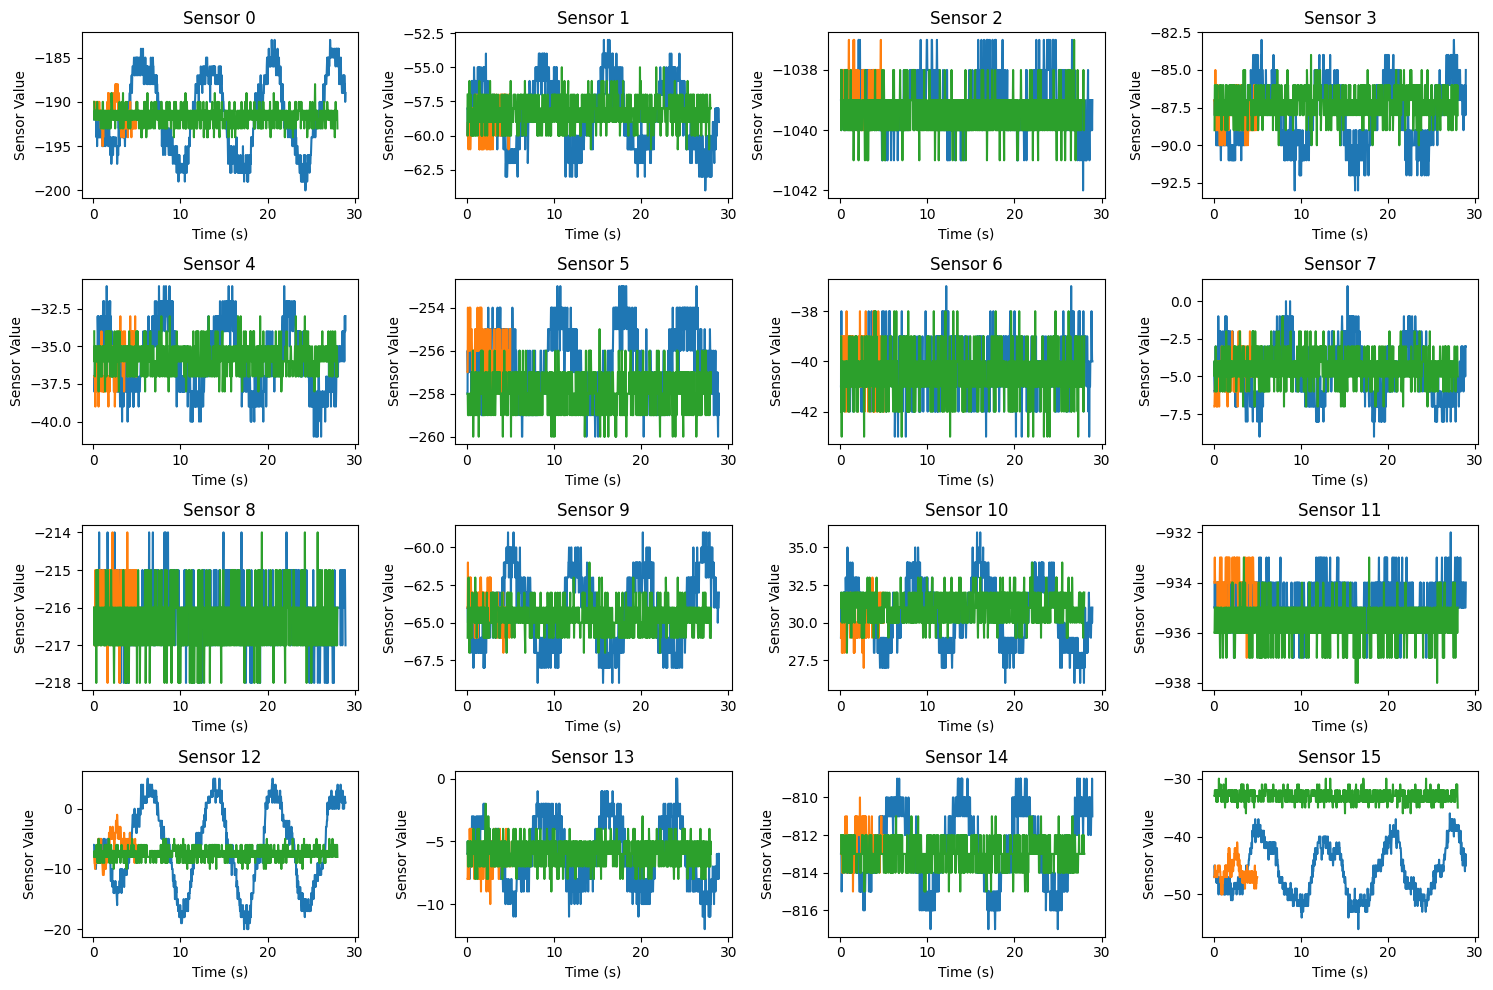

In [6]:
data_path = "G:\\datasets\\tac2Slip\\severity-03-15"
classes = ['salt-no-slip', 'salt', 'non-contact']
import os
import csv
import time
import numpy as np
def import_csv(file_path):
    with open(file_path, 'r') as f:
        reader = csv.reader(f)
        #skip header
        next(reader)
        data = []
        for row in reader:
            data.append([float(i) for i in row])
    data = np.array(data, dtype=np.float32)
    time = data[:, 0]
    data = data[:, 1:]
    return time, data

c = 1
i = 0
file_path = os.path.join(data_path, classes[1], f"tactile_data{i:04d}.csv")
time_slip, data_slip = import_csv(file_path)

print(f"{data_slip.shape=}")
print(f"{time_slip.shape=}")

file_path = os.path.join(data_path, classes[0], f"tactile_data{i:04d}.csv")
time_no_slip, data_no_slip = import_csv(file_path)
print(f"{data_no_slip.shape=}")
print(f"{time_no_slip.shape=}")

file_path = os.path.join(data_path, classes[2], f"tactile_data{i:04d}.csv")
time_non_contact, data_non_contact = import_csv(file_path)
print(f"{data_non_contact.shape=}")
print(f"{time_non_contact.shape=}")

# --------------------------- Plot first 16 channels across time -------------------------- #
import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 4, figsize=(15, 10))
for j in range(16):
    ax = axs[j // 4, j % 4]
    ax.plot(time_slip, data_slip[:, j])
    ax.plot(time_no_slip, data_no_slip[:, j])
    ax.plot(time_non_contact, data_non_contact[:, j])
    ax.set_title(f'Sensor {j}')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Sensor Value')
plt.tight_layout()
plt.show()

Finger 0: data_finger_slip_magnitude.shape=(869, 17), data_finger_no_slip_magnitude.shape=(149, 17), data_finger_non_contact_magnitude.shape=(839, 17)


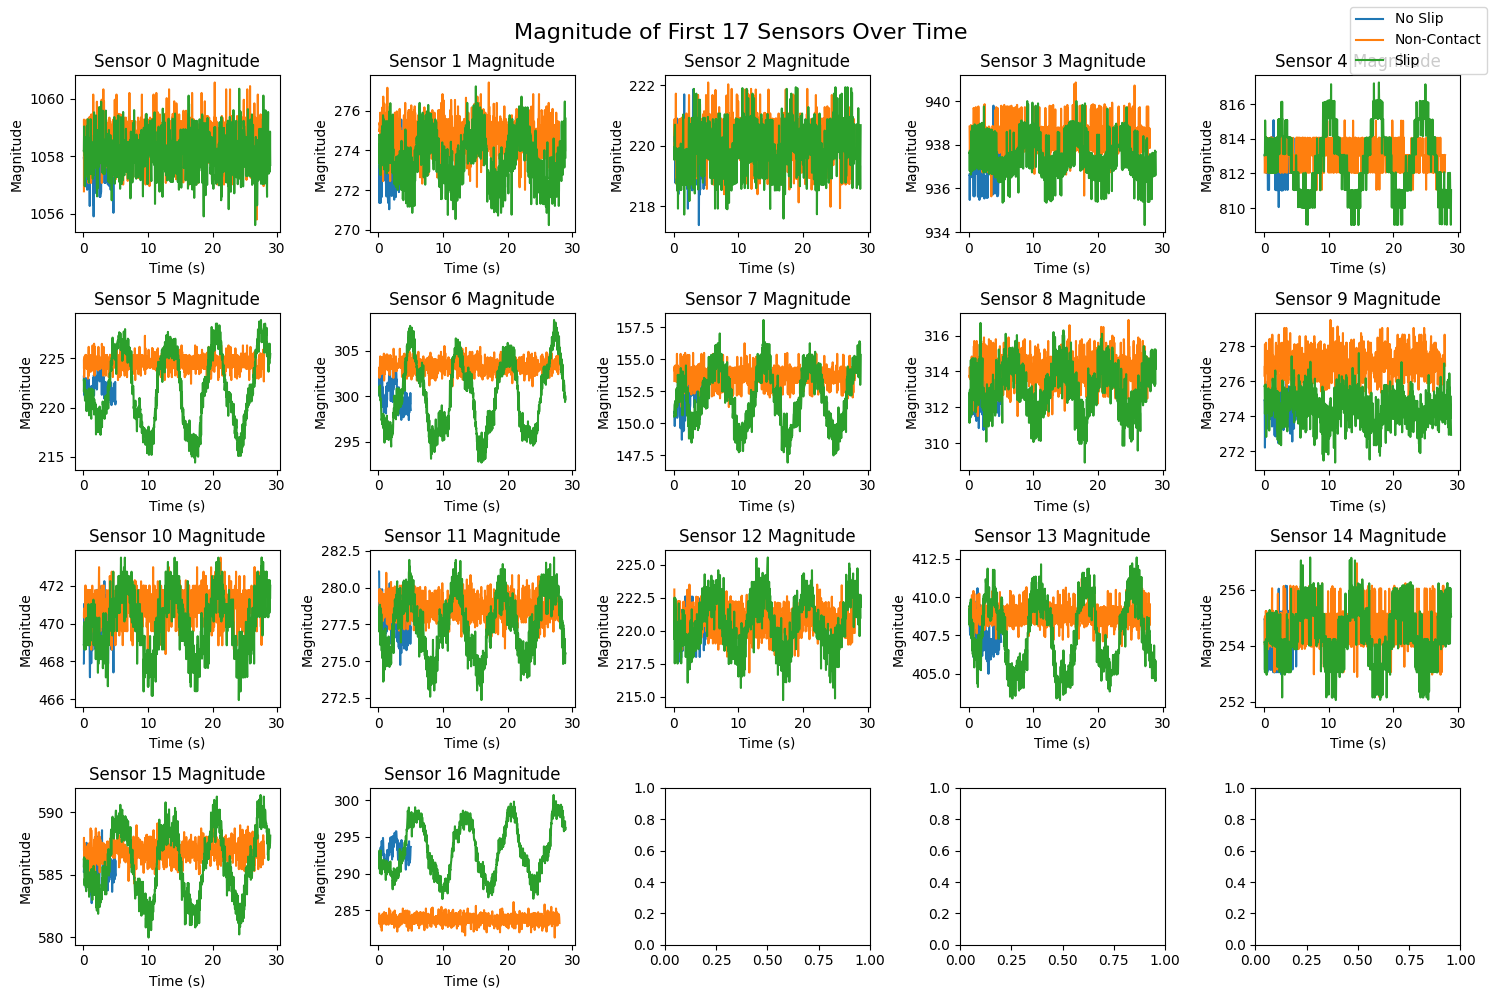

Finger 1: data_finger_slip_magnitude.shape=(869, 17), data_finger_no_slip_magnitude.shape=(149, 17), data_finger_non_contact_magnitude.shape=(839, 17)


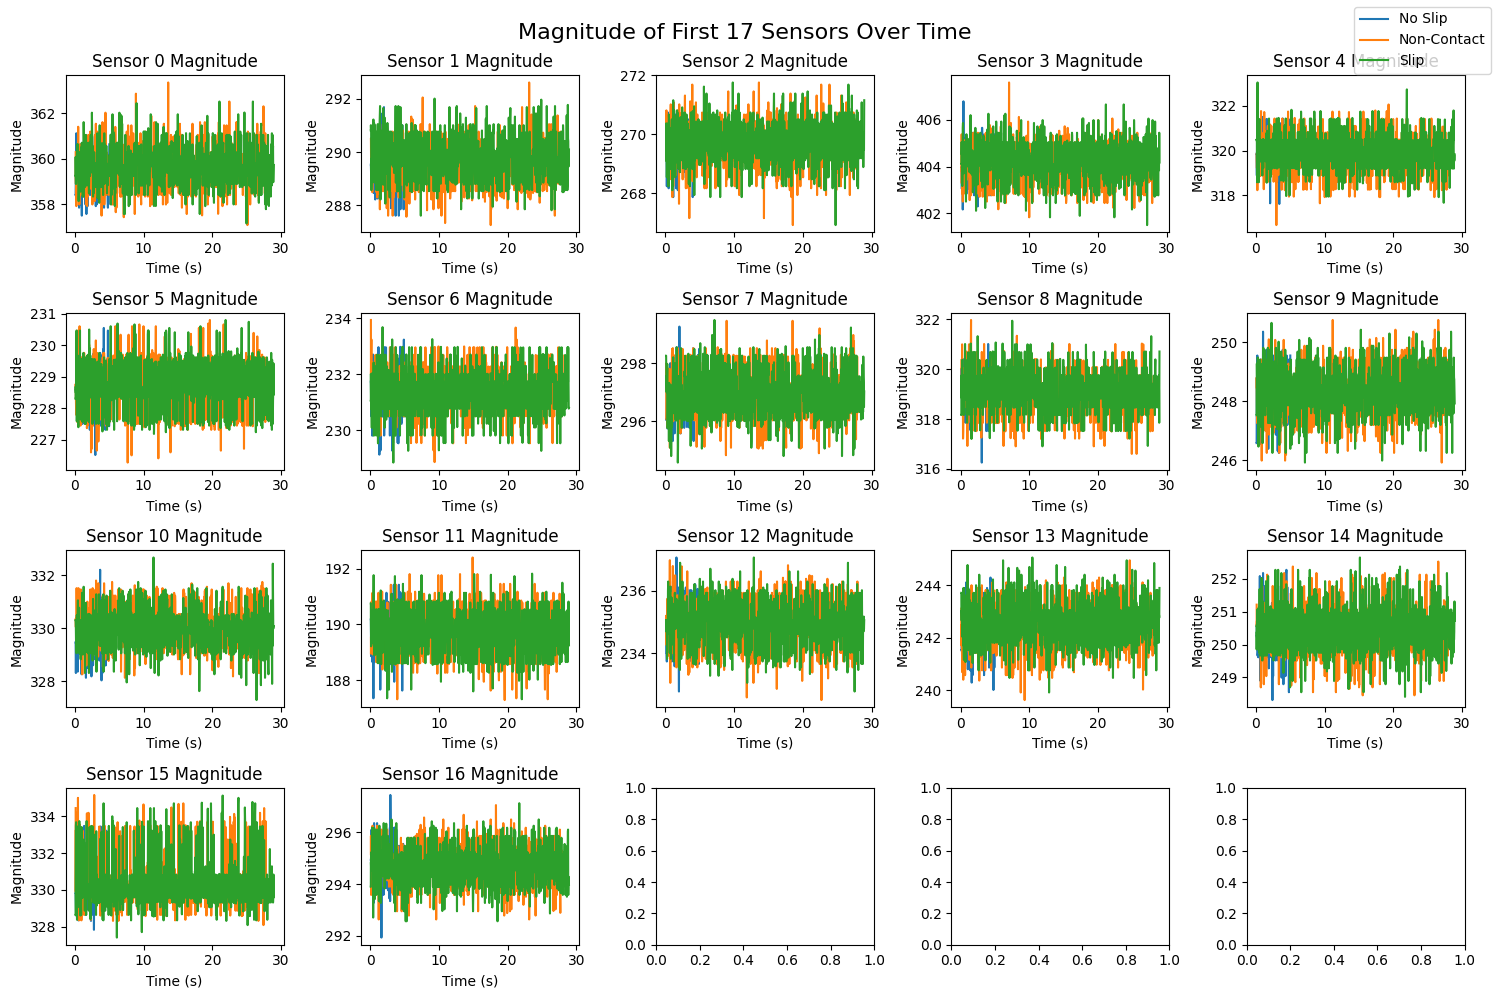

Finger 2: data_finger_slip_magnitude.shape=(869, 17), data_finger_no_slip_magnitude.shape=(149, 17), data_finger_non_contact_magnitude.shape=(839, 17)


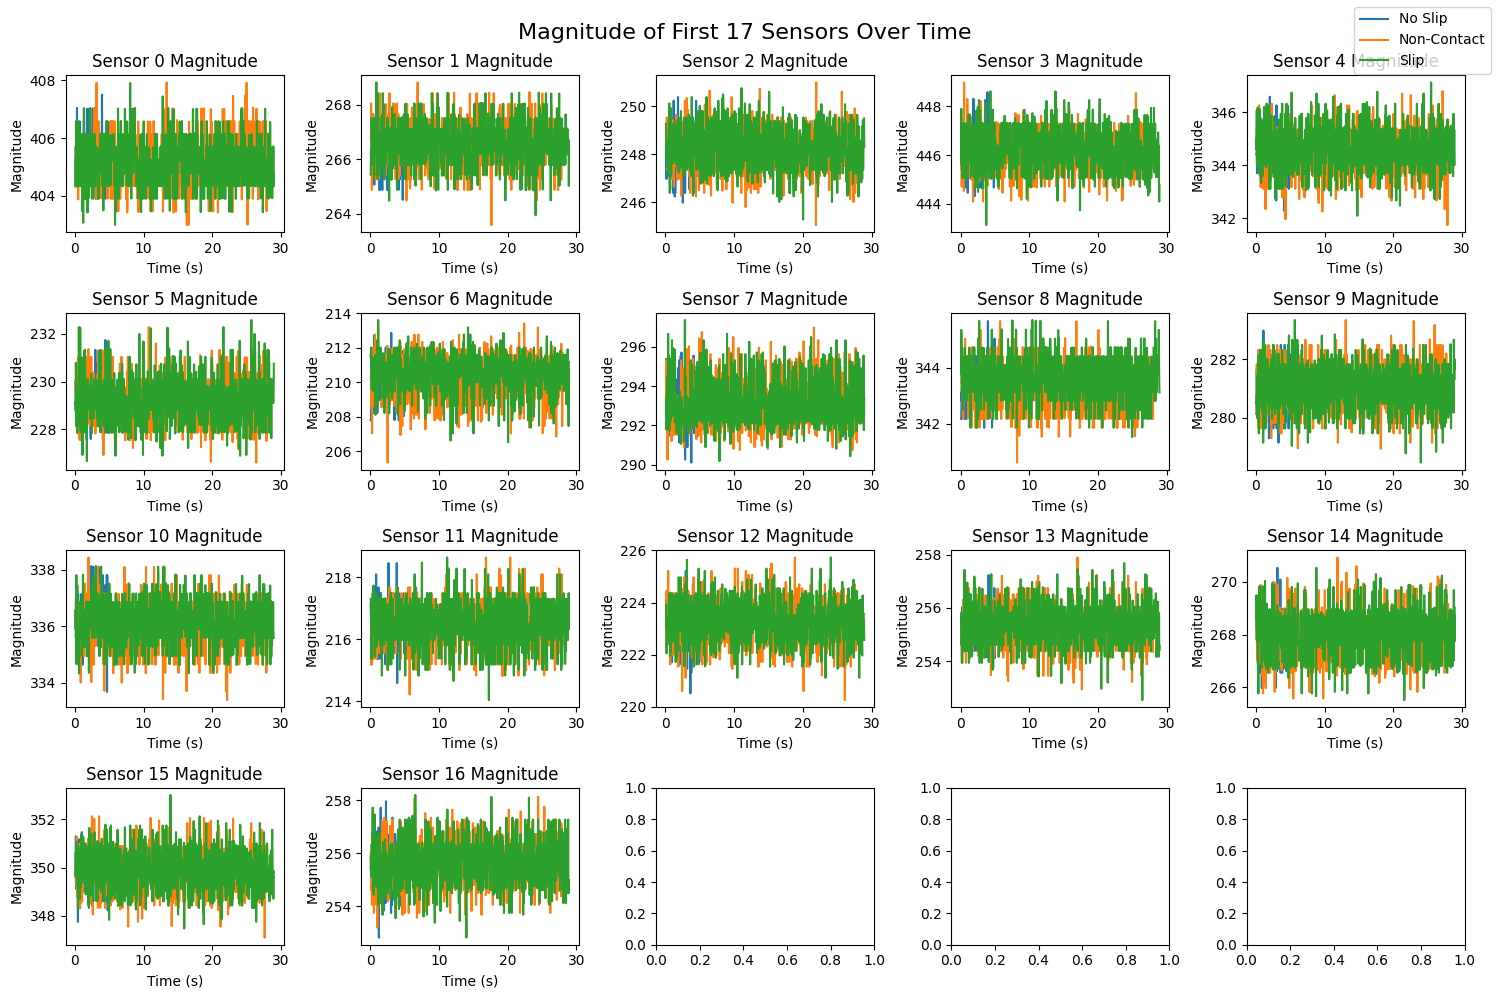

Finger 3: data_finger_slip_magnitude.shape=(869, 17), data_finger_no_slip_magnitude.shape=(149, 17), data_finger_non_contact_magnitude.shape=(839, 17)


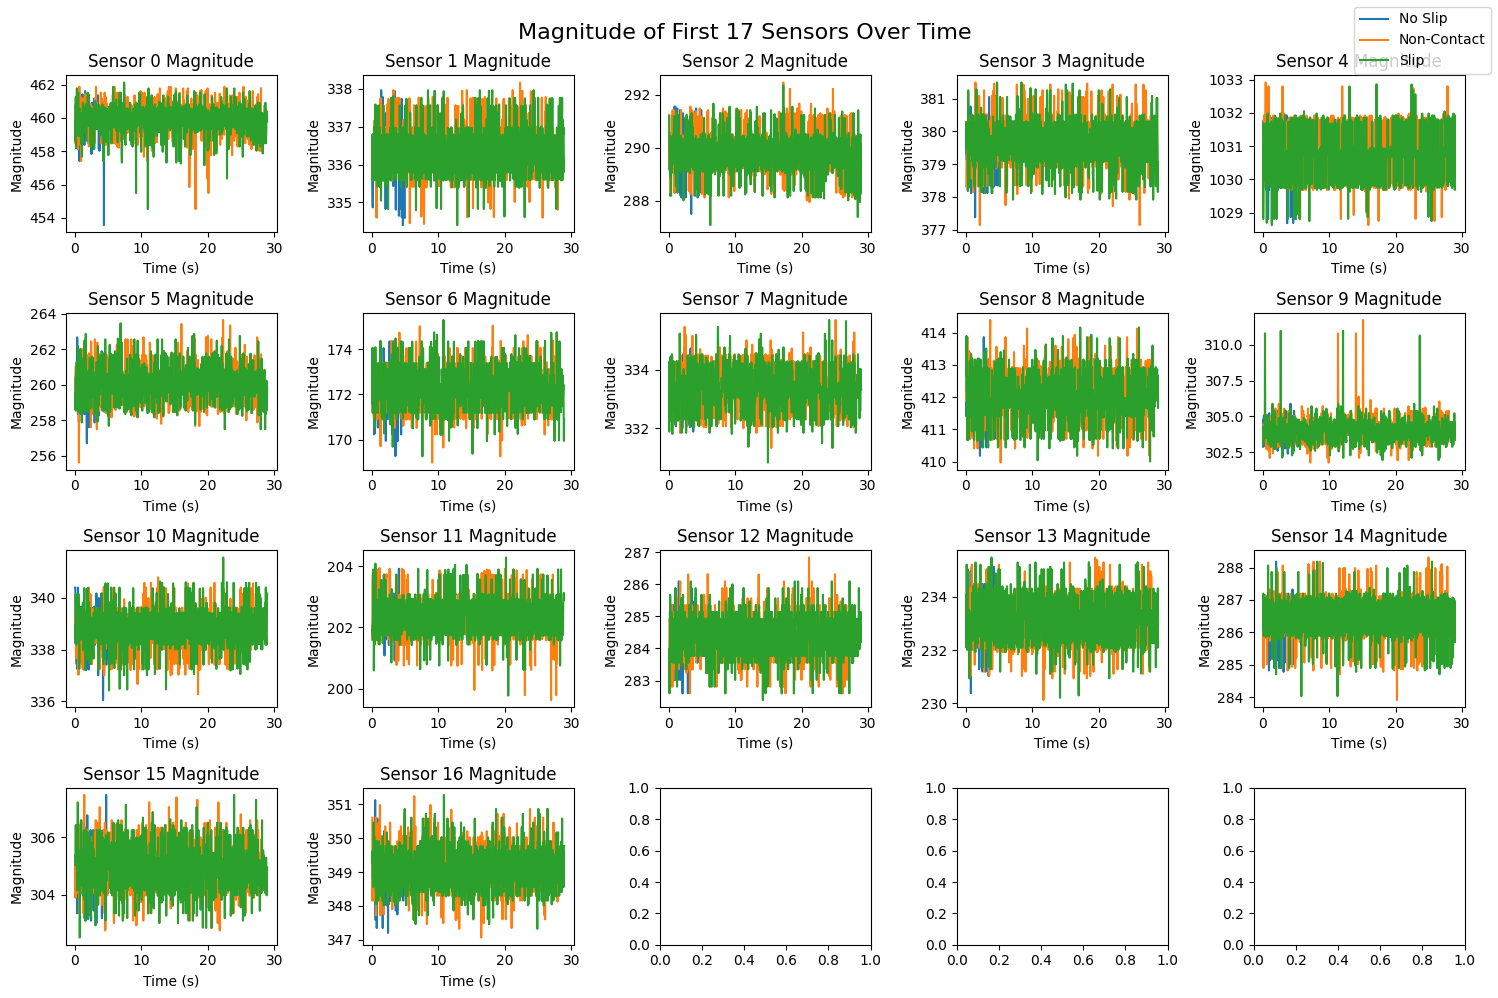

Finger 4: data_finger_slip_magnitude.shape=(869, 17), data_finger_no_slip_magnitude.shape=(149, 17), data_finger_non_contact_magnitude.shape=(839, 17)


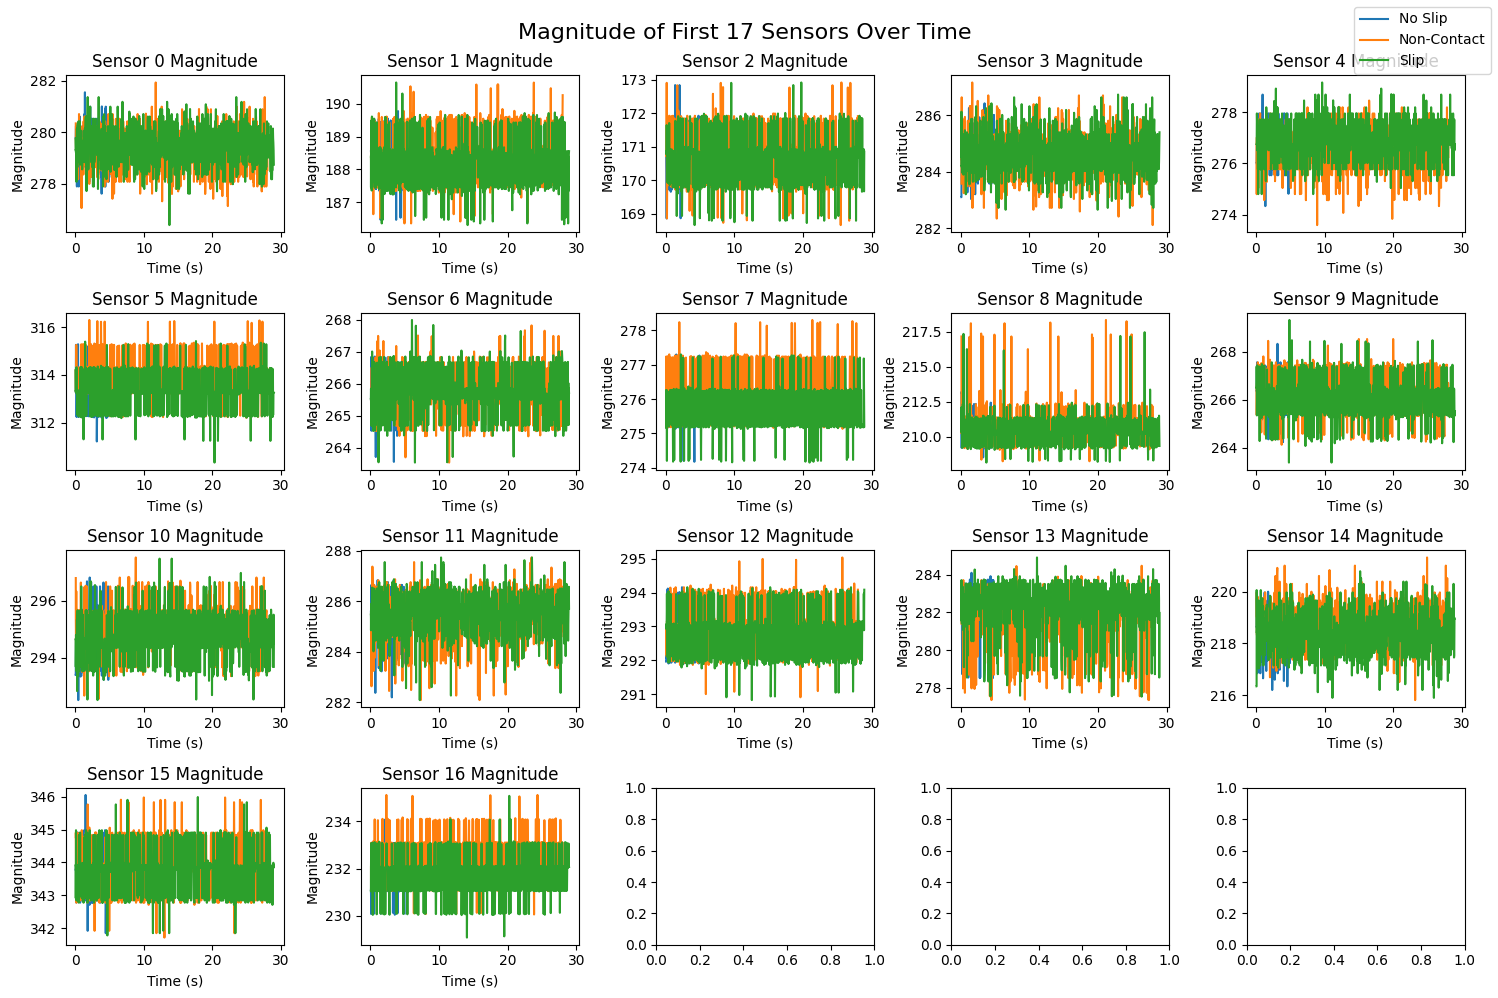

In [12]:

for f in range(5):
    data_finger_slip_magnitude = np.sqrt(np.sum(data_slip[:, f*51:(f+1)*51].reshape(-1, 17, 3)**2, axis=2))
    data_finger_no_slip_magnitude = np.sqrt(np.sum(data_no_slip[:, f*51:(f+1)*51].reshape(-1, 17, 3)**2, axis=2))
    data_finger_non_contact_magnitude = np.sqrt(np.sum(data_non_contact[:, f*51:(f+1)*51].reshape(-1, 17, 3)**2, axis=2))
    print(f"Finger {f}: {data_finger_slip_magnitude.shape=}, {data_finger_no_slip_magnitude.shape=}, {data_finger_non_contact_magnitude.shape=}")

    # ----------------------------------- Plot ----------------------------------- #
    # Plot the magnitude of the first 17 sensors
    fig, axs = plt.subplots(4, 5, figsize=(15, 10))
    for j in range(17):
        ax = axs[j // 5, j % 5]
        ax.plot(time_no_slip, data_finger_no_slip_magnitude[:, j])
        ax.plot(time_non_contact, data_finger_non_contact_magnitude[:, j])
        ax.plot(time_slip, data_finger_slip_magnitude[:, j])
        ax.set_title(f'Sensor {j} Magnitude')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Magnitude')
    #Add title to the figure
    fig.suptitle('Magnitude of First 17 Sensors Over Time', fontsize=16)
    fig.legend(['No Slip', 'Non-Contact','Slip'], loc='upper right')
    plt.tight_layout()
    plt.show()